# GAN (Generative Adversarial Networks)

En este practico vamos a estar implementando el modelo generativo [GAN (Generative Adversarial Networks)](https://arxiv.org/pdf/1406.2661)

In [1]:
import os
import math
import torch
import numpy as np
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torchvision.utils as vutils
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from mpl_toolkits.axes_grid1 import ImageGrid

os.makedirs("./output_images", exist_ok=True)

In [2]:
# Transformamos los datos a tensores y los normalizamos
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
    ])

# Descargamos el dataset
dataset = datasets.FashionMNIST(root='./data', download=True, transform=transform)

# Creamos el dataloader
batch_size = 64
dataloader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)

device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Running on {device}")

100%|██████████| 26.4M/26.4M [00:05<00:00, 5.11MB/s]


Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 125kB/s]


Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 4.42M/4.42M [00:01<00:00, 2.31MB/s]


Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 4.82MB/s]

Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw

Running on cuda


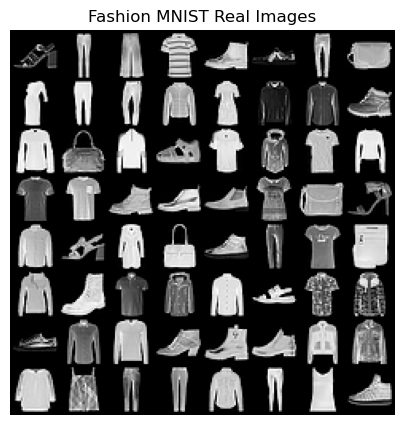

In [3]:
def show_imgs(imgs, title="Images", save_path=None):
    plt.figure(figsize=(5,5))
    plt.axis("off")
    plt.title(title)
    plt.imshow(np.transpose(vutils.make_grid(imgs, padding=2, normalize=True).cpu(),(1,2,0)))
    if save_path:
        plt.savefig(save_path)
    plt.show()

real_batch = next(iter(dataloader))[0][:64]
img_shape = real_batch[0].shape
show_imgs(real_batch, title="Fashion MNIST Real Images", save_path="./output_images/real_fmnist.png")

## Definimos el modelo
Las GANs (Generative Adversarial Networks) consisten en dos redes que compiten entre sí: un generador que crea datos falsos y un discriminador que trata de distinguirlos de los datos reales, mejorando así la calidad de los datos generados con el tiempo.

### Generador
Es una red neuronal que, partiendo de un espacio latente, crea datos sintéticos con el objetivo de parecerse a los datos reales.

Esta "parte" del modelo es la que nos va a servir luego para la generación.

In [4]:
class Generator(nn.Module):
    def __init__(self, latent_dim, number_feature_maps, output_channels):
        super(Generator, self).__init__()
        self.latent_feature_maps = latent_dim
        self.main = nn.Sequential(
            # Tamaño entrada (bs, tamaño latente, 1, 1)
            nn.ConvTranspose2d(latent_dim, number_feature_maps * 4, 7, 1, 0, bias=False),
            nn.BatchNorm2d(number_feature_maps * 4),
            nn.ReLU(True),
            # Tamaño (bs, number_feature_maps*4, 7 , 7)
            nn.ConvTranspose2d(number_feature_maps * 4, number_feature_maps * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(number_feature_maps * 2),
            nn.ReLU(True),
            # Tamaño (bs, number_feature_maps*2, 14 , 14)
            nn.ConvTranspose2d(number_feature_maps * 2, number_feature_maps, 4, 2, 1, bias=False),
            nn.BatchNorm2d(number_feature_maps),
            nn.ReLU(True),
            # Tamaño (bs, number_feature_maps, 28 , 28)
            nn.ConvTranspose2d(number_feature_maps, output_channels, 3, 1, 1, bias=False),
            nn.Tanh(),
            # Tamaño salida (bs, 1, 28 , 28)
        )

    def forward(self, input):
        result = self.main(input)
        return result

### Discriminador

Es una red neuronal que clasifica los datos como reales o generados. Su tarea es distinguir entre los datos reales y los falsos producidos por el generador, ayudando así a mejorar la calidad de ambos.

In [5]:
class Discriminator(nn.Module):
    def __init__(self, input_channels, number_feature_maps, output_dim):
        super(Discriminator, self).__init__()
        self.conv_layers = nn.Sequential(
            # Tamaño entrada (bs, 1, 28, 28)
            nn.Conv2d(input_channels, number_feature_maps, 4, 2, 1, bias=False),
            nn.BatchNorm2d(number_feature_maps),
            nn.LeakyReLU(0.2, inplace=True),
            # Tamaño (bs, number_feature_maps, 14, 14)
            nn.Conv2d(number_feature_maps, number_feature_maps * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(number_feature_maps * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # Tamaño (bs, number_feature_maps*2, 7, 7)
            nn.Conv2d(number_feature_maps * 2, number_feature_maps * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(number_feature_maps * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # Tamaño (bs, number_feature_maps*4, 4, 4)
        )

        self.fully_connected = nn.Sequential(
            nn.Flatten(1),
            # Tamaño (bs, 3*3*number_feature_maps*4)
            nn.Linear(3*3*number_feature_maps*4, output_dim),
            nn.Sigmoid()
        )

    def forward(self, input):
        res = self.conv_layers(input)
        res = self.fully_connected(res)
        return res

## Definición de hyperparámetros y creación del modelo.

In [6]:
LATENT_DIM = 100
NUMBER_FEATURE_MAPS = 32
OUTPUT_CHANNELS = 1
INPUT_CHANNELS = 1
OUTPUT_DIM = 1
DISCRIMINATOR_LR = 0.0002
GENERATOR_LR = 0.002
N_EPOCHS = 12

generator = Generator(LATENT_DIM, NUMBER_FEATURE_MAPS, OUTPUT_CHANNELS).to(device)
discriminator = Discriminator(INPUT_CHANNELS, NUMBER_FEATURE_MAPS, OUTPUT_DIM).to(device)

adversarial_loss = nn.BCELoss()

In [7]:
def train(generator, discriminator, adversarial_loss, dataloader, n_epochs, device, verbose=False):
    optimizer_G = optim.Adam(generator.parameters(), lr=GENERATOR_LR)
    optimizer_D = optim.Adam(discriminator.parameters(), lr=DISCRIMINATOR_LR)

    for epoch in tqdm(range(n_epochs)):
        for i, (imgs, _) in enumerate(dataloader):
            bs = imgs.size(0)

            valid = torch.ones(bs, 1).to(device)
            fake = torch.zeros(bs, 1).to(device)

            real_imgs = imgs.to(device)

            latent_shape = (bs, LATENT_DIM, 1, 1)
            z = torch.randn(latent_shape).to(device)

            optimizer_G.zero_grad()
            gen_imgs = generator(z)
            g_loss = adversarial_loss(discriminator(gen_imgs), valid)
            g_loss.backward()
            optimizer_G.step()

            optimizer_D.zero_grad()
            real_loss = adversarial_loss(discriminator(real_imgs), valid)
            fake_loss = adversarial_loss(discriminator(gen_imgs.detach()), fake)
            d_loss = (real_loss + fake_loss) / 2
            d_loss.backward()
            optimizer_D.step()

            if verbose: 
                print(f"[Epoch {epoch}/{n_epochs}] [Batch {i}/{len(dataloader)}] [D loss: {d_loss.item()}] [G loss: {g_loss.item()}]")

        if epoch % 4 == 0:
            save_path = f"./output_images/fmnist_epoch_{epoch}.png"
            show_imgs(gen_imgs.data[:32], title=f"Epoch {epoch}", save_path=save_path)

## Entrenamiento del modelo

  0%|          | 0/12 [00:00<?, ?it/s]

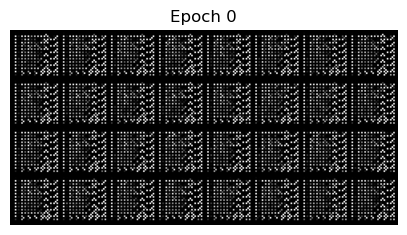

 33%|███▎      | 4/12 [01:03<01:51, 13.94s/it]

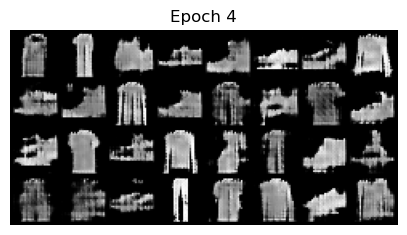

 67%|██████▋   | 8/12 [02:25<01:17, 19.47s/it]

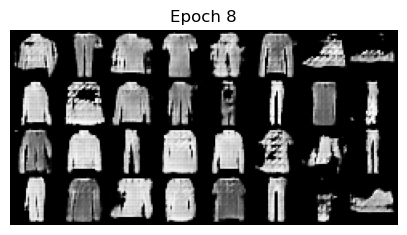

100%|██████████| 12/12 [03:35<00:00, 17.95s/it]


In [8]:
train(generator, discriminator, adversarial_loss, dataloader, N_EPOCHS, device)

## Generación de datos

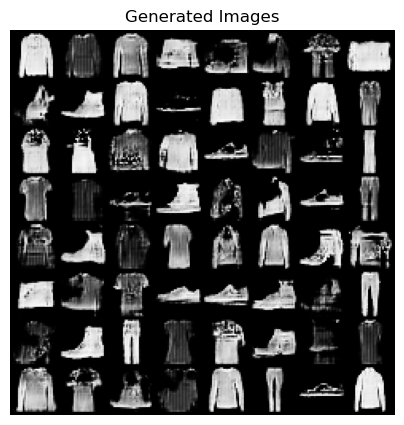

In [9]:
def generate(generator, num_imgs=32):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(num_imgs, LATENT_DIM, 1, 1).to(device)
        gen_imgs = generator(z)
    generator.train()
    return gen_imgs

imgs = generate(generator, num_imgs=64)
show_imgs(imgs, title="Generated Images", save_path="./output_images/fmnist_generated_final.png")

## Ejercicios:

1. Complete el codigo faltante y entrene una GAN que genere imágenes de Fashion MNIST.
2. Responda las siguientes preguntas:
    - ¿En qué afecta el tamaño del espacio latente?
    - ¿Por qué entrenamos al discriminador y al generador alternativamente?
    - ¿Qué tamaño tiene la salida del discriminador y por qué? ¿Y el generador?
    - ¿Qué tipo de activación final se usa en el discriminador y por qué?
    - ¿Cuál es el propósito de la competencia entre el generador y el discriminador en las GANs? Explica cómo esto contribuye a la mejora del modelo.
    - Entrene una GAN que genere imágenes del dataset [SVHN (street view house number)](http://ufldl.stanford.edu/housenumbers/).
    - Comente los resultados obtenidos con este dataset.

### Respuestas:

  ¿En qué afecta el tamaño del espacio latente?

  El espacio latente es básicamente cuánta información tenés para generar las imágenes. Si es muy chico no te alcanza para representar todas las variaciones que querés generar, te limita la diversidad. Si es muy grande tarda más, pero te da más variedad en lo que generás.

  ¿Por qué entrenamos al discriminador y al generador alternativamente?

  Porque tienen objetivos opuestos digamos. Si los entrenás a los dos juntos al mismo tiempo se te mezclan los gradientes y no sabés bien qué parámetros tocar para cada uno. Entonces los entrenás alternados, un rato el discriminador aprende a detectar mejor las imágenes falsas, y después el generador aprende a engañarlo. Es como el juego del policía y el ladrón que vimos en clase, uno mejora y después el otro tiene que mejorar para seguir en el juego.

  ¿Qué tamaño tiene la salida del discriminador y por qué? ¿Y el generador?

  El discriminador tiene salida de 1, un valor entre 0 y 1, porque es un clasificador binario que te dice si la imagen es real o falsa. El generador tiene que sacar imágenes del mismo tamaño que el dataset, o sea en Fashion MNIST sería 1x28x28, porque tiene que generar imágenes que parezcan del dataset real.

  ¿Qué tipo de activación final se usa en el discriminador y por qué?

  Se usa Sigmoid porque necesitás un valor entre 0 y 1 que es la probabilidad de que la imagen sea real. Sigmoid te toma cualquier valor y te lo mete en ese rango, entonces es ideal para
  clasificación binaria.

  ¿Cuál es el propósito de la competencia entre el generador y el discriminador en las GANs? Explica cómo esto contribuye a la mejora del modelo.

  La idea es que los dos se vayan mejorando mutuamente. El generador intenta hacer imágenes cada vez más realistas para engañar al discriminador, y el discriminador trata de no dejarse engañar y detectar mejor las falsas. Entonces esa competencia hace que el generador termine aprendiendo a generar imágenes muy parecidas a las reales, porque tiene que ser lo suficientemente bueno para confundir a un discriminador que también está mejorando. Si llegás a un equilibrio donde el discriminador no sabe distinguir bien, es porque el generador está generando cosas muy buenas.

  ---

Estas imágenes son de (3, 32, 32). Debe crear un nuevo generador y dicriminador para ajustarse a estas nuevas dimensiones.

100%|██████████| 182M/182M [00:54<00:00, 3.37MB/s] 


Image size: torch.Size([3, 32, 32])


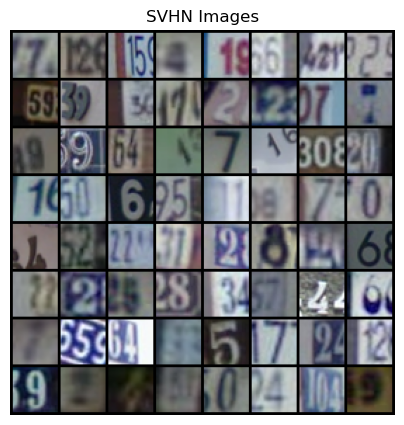

In [10]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(0, 1)
    ])

dataset = datasets.SVHN(root='./data', download=True, transform=transform)
print(f"Image size: {dataset[0][0].shape}")

batch_size = 64
dataloader = DataLoader(dataset=dataset, batch_size=batch_size, shuffle=True)
real_batch = next(iter(dataloader))[0]
img_shape = real_batch[0].shape
show_imgs(real_batch, "SVHN Images")

### Definición de modelos para SVHN

In [11]:
class GeneratorSVHN(nn.Module):
    def __init__(self, latent_dim, number_feature_maps, output_channels):
        super(GeneratorSVHN, self).__init__()
        self.latent_feature_maps = latent_dim
        self.main = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, number_feature_maps * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(number_feature_maps * 8),
            nn.ReLU(True),
            nn.ConvTranspose2d(number_feature_maps * 8, number_feature_maps * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(number_feature_maps * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(number_feature_maps * 4, number_feature_maps * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(number_feature_maps * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(number_feature_maps * 2, output_channels, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, input):
        return self.main(input)

In [12]:
class DiscriminatorSVHN(nn.Module):
    def __init__(self, input_channels, number_feature_maps, output_dim):
        super(DiscriminatorSVHN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(input_channels, number_feature_maps, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(number_feature_maps, number_feature_maps * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(number_feature_maps * 2),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(number_feature_maps * 2, number_feature_maps * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(number_feature_maps * 4),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(number_feature_maps * 4, number_feature_maps * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(number_feature_maps * 8),
            nn.LeakyReLU(0.2, inplace=True),
        )
        
        self.fully_connected = nn.Sequential(
            nn.Flatten(1),
            nn.Linear(number_feature_maps * 8 * 2 * 2, output_dim),
            nn.Sigmoid()
        )

    def forward(self, input):
        res = self.conv_layers(input)
        res = self.fully_connected(res)
        return res

### Hiperparámetros y creación de modelos para SVHN

In [13]:
LATENT_DIM_SVHN = 100
NUMBER_FEATURE_MAPS_SVHN = 32
OUTPUT_CHANNELS_SVHN = 3
INPUT_CHANNELS_SVHN = 3
OUTPUT_DIM_SVHN = 1
DISCRIMINATOR_LR_SVHN = 0.0002
GENERATOR_LR_SVHN = 0.002
N_EPOCHS_SVHN = 12

generator_svhn = GeneratorSVHN(LATENT_DIM_SVHN, NUMBER_FEATURE_MAPS_SVHN, OUTPUT_CHANNELS_SVHN).to(device)
discriminator_svhn = DiscriminatorSVHN(INPUT_CHANNELS_SVHN, NUMBER_FEATURE_MAPS_SVHN, OUTPUT_DIM_SVHN).to(device)

adversarial_loss_svhn = nn.BCELoss()

### Entrenamiento con SVHN

  0%|          | 0/12 [00:00<?, ?it/s]

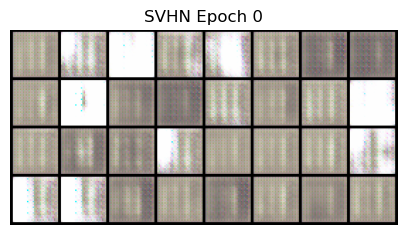

 33%|███▎      | 4/12 [01:43<03:28, 26.09s/it]

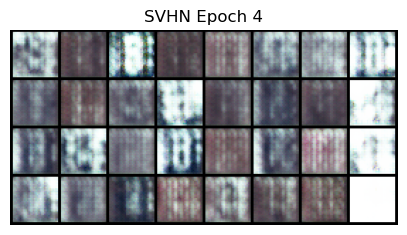

 67%|██████▋   | 8/12 [03:28<01:40, 25.03s/it]

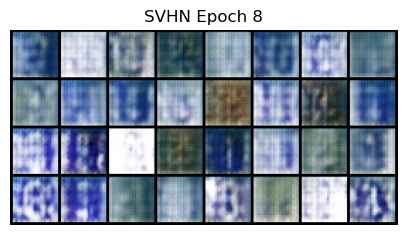

100%|██████████| 12/12 [05:22<00:00, 26.87s/it]


In [14]:
def train_svhn(generator, discriminator, adversarial_loss, dataloader, n_epochs, device, latent_dim, verbose=False):
    optimizer_G = optim.Adam(generator.parameters(), lr=GENERATOR_LR_SVHN)
    optimizer_D = optim.Adam(discriminator.parameters(), lr=DISCRIMINATOR_LR_SVHN)

    for epoch in tqdm(range(n_epochs)):
        for i, (imgs, _) in enumerate(dataloader):
            bs = imgs.size(0)

            valid = torch.ones(bs, 1).to(device)
            fake = torch.zeros(bs, 1).to(device)

            real_imgs = imgs.to(device)

            latent_shape = (bs, latent_dim, 1, 1)
            z = torch.randn(latent_shape).to(device)

            optimizer_G.zero_grad()
            gen_imgs = generator(z)
            g_loss = adversarial_loss(discriminator(gen_imgs), valid)
            g_loss.backward()
            optimizer_G.step()

            optimizer_D.zero_grad()
            real_loss = adversarial_loss(discriminator(real_imgs), valid)
            fake_loss = adversarial_loss(discriminator(gen_imgs.detach()), fake)
            d_loss = (real_loss + fake_loss) / 2
            d_loss.backward()
            optimizer_D.step()

            if verbose: 
                print(f"[Epoch {epoch}/{n_epochs}] [Batch {i}/{len(dataloader)}] [D loss: {d_loss.item()}] [G loss: {g_loss.item()}]")

        if epoch % 4 == 0:
            save_path = f"./output_images/svhn_epoch_{epoch}.png"
            show_imgs(gen_imgs.data[:32], title=f"SVHN Epoch {epoch}", save_path=save_path)

train_svhn(generator_svhn, discriminator_svhn, adversarial_loss_svhn, dataloader, N_EPOCHS_SVHN, device, LATENT_DIM_SVHN)

### Generación de imágenes SVHN

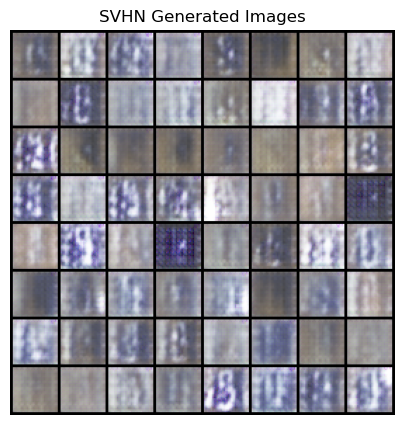

In [15]:
def generate_svhn(generator, num_imgs, latent_dim):
    generator.eval()
    with torch.no_grad():
        z = torch.randn(num_imgs, latent_dim, 1, 1).to(device)
        gen_imgs = generator(z)
    generator.train()
    return gen_imgs

imgs_svhn = generate_svhn(generator_svhn, num_imgs=64, latent_dim=LATENT_DIM_SVHN)
show_imgs(imgs_svhn, title="SVHN Generated Images", save_path="./output_images/svhn_generated_final.png")

### Comente los resultados obtenidos con este dataset.

  SVHN es bastante más complicado que Fashion MNIST. Primero porque las imágenes son a color, entonces el generador tiene que aprender a generar combinaciones de RGB que tengan sentido, no es como escala de grises que es más directo.

  Después las imágenes son de 32x32 en vez de 28x28, y son números fotografiados en la calle, entonces tenés más variabilidad en los fondos, la luz, etc. Por eso tuvimos que hacer un generador y discriminador con más capas convolucionales para soportar los 3 canales y la resolución.

  El entrenamiento es más inestable con SVHN, el discriminador aprende muy rápido al principio y después el generador se tiene que esforzar más para alcanzarlo. Se nota que generar dígitos con fondos naturales es mucho más difícil que generar ropa en escala de grises. Al principio salen puros colores mezclados medio random, y después de varias épocas recién empiezan a aparecer formas que se parecen a números.